# Aula 03 — Computação Quântica: Uma Abordagem Hands-On
## Ruído em Simulações Quânticas

Computadores quânticos reais não são perfeitos. Cada operação introduz pequenos erros. Entender como modelar esse ruído é essencial para desenvolver algoritmos robustos e preparar-se para a era do hardware real.


## 1.  Instalação das Bibliotecas

In [ ]:
!pip install qiskit qiskit-aer qiskit-ibm-runtime pylatexenc matplotlib numpy -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 10.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 205.3/205.3 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 7.2 MB/s eta 0:00:00


## 2. O Que é Ruído Quântico?

Em hardware quântico real, algumas fontes principais de erro afetam os cálculos:

Tipos principais de ruído:

| Tipo | Símbolo físico | Descrição |
|------|---------------|-----------|
| **Amplitude Damping** | $T_1$ | Relaxação para o estado fundamental |
| **Bit Flip** | — | Inversão aleatória do qubit ($|0\rangle \leftrightarrow |1\rangle$) |
| **Dephasing (Defasagem)** | $T_2$ | Perda de coerência de fase |
| **Depolarizing** | — | Canal de ruído mais geral |
| **SPAM** | — | Erro na preparação e medição |
### Intuição

Pense nos qubits como objetos extremamente frágeis, sensíveis a vibração e temperatura.  
Cada operação tem uma certa chance de errar. O objetivo é:
1. **Modelar** esse ruído para simulações realistas
2. **Mitigar** os efeitos usando técnicas inteligentes

---

### Canais de Ruído Quântico

Matematicamente, ruído é descrito por **operadores de Kraus** que ao invés de estados puros $|\psi\rangle$, passamos a trabalhar com **matrizes de densidade** $\rho$.

$$\rho \mapsto \mathcal{E}(\rho) = \sum_k K_k \rho K_k^\dagger$$

onde os $K_k$ são os **operadores de Kraus** satisfazendo $\sum_k K_k^\dagger K_k = I$.
- **Bit-flip (X):** com probabilidade `p`, aplica porta X (inverte o bit)
- **Phase-flip (Z):** com probabilidade `p`, aplica porta Z (inverte a fase)
- **Depolarização:** com probabilidade `p`, aplica X, Y ou Z aleatoriamente
- **Amplitude damping:** modela relaxação T1 (qubit decai de |1⟩ → |0⟩)


## 3.  Modelos de Ruído com Qiskit Aer

O `qiskit-aer` oferece uma API completa para construir **modelos de ruído customizados**.

In [ ]:
# Imports principais da aula
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram, circuit_drawer
from qiskit_aer import AerSimulator
from qiskit_aer.noise import (
    NoiseModel,
    depolarizing_error,
    pauli_error,
    amplitude_damping_error,
    phase_damping_error,
    ReadoutError,
    thermal_relaxation_error
)
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

print(" Todos os imports carregados com sucesso!")


 Todos os imports carregados com sucesso!


### 3.1 Erro de Bit-Flip (Pauli)

O erro mais simples: com probabilidade `p`, o qubit é flipado (0↔1).

In [ ]:
# ── Erro de Bit-Flip ────────────────────────────────────────────
p_erro = 0.1  # 10% de chance de erro por porta

# Define o erro de Pauli: 10% X (bit-flip), 0% Y, 0% Z
erro_x = pauli_error([("X", p_erro), ("I", 1 - p_erro)])

# Cria o modelo de ruído
noise_model_bitflip = NoiseModel()

# Aplica o erro apenas em portas de 1 qubit
noise_model_bitflip.add_all_qubit_quantum_error(erro_x, ["x", "h"])

print("Modelo de ruído (bit-flip):")
print(noise_model_bitflip)


Modelo de ruído (bit-flip):
NoiseModel:
  Basis gates: ['cx', 'h', 'id', 'rz', 'sx', 'x']
  Instructions with noise: ['h', 'x']
  All-qubits errors: ['x', 'h']


### 3.2 Erro de Depolarização

Mais realista: com probabilidade `p`, aplica X, Y ou Z com igual probabilidade.

In [ ]:
# ── Erro de Depolarização ──────────────────────────────────────
p_dep_1q = 0.01   # 1% de erro em portas de 1 qubit
p_dep_2q = 0.05   # 5% de erro em portas de 2 qubits (CNOT é mais ruidosa)

erro_dep_1q = depolarizing_error(p_dep_1q, 1)
erro_dep_2q = depolarizing_error(p_dep_2q, 2)

noise_model_dep = NoiseModel()
noise_model_dep.add_all_qubit_quantum_error(erro_dep_1q, ["h", "x", "ry", "rz"])
noise_model_dep.add_all_qubit_quantum_error(erro_dep_2q, ["cx"])

print("Modelo de ruído (depolarização):")
print(noise_model_dep)


Modelo de ruído (depolarização):
NoiseModel:
  Basis gates: ['cx', 'h', 'id', 'ry', 'rz', 'sx', 'x']
  Instructions with noise: ['h', 'cx', 'ry', 'x', 'rz']
  All-qubits errors: ['h', 'x', 'ry', 'rz', 'cx']


### 3.3 Erro de Medição (Readout Error)

Quando o hardware lê o qubit, pode confundir 0 com 1 e vice-versa.

In [ ]:
# ── Erro de Medição ─────────────────────────────────────────────
# Matriz de confusão:
# p(0|0) = prob de medir 0 dado que o estado era 0
# p(1|0) = prob de medir 1 dado que o estado era 0
p_medir_errado = 0.05  # 5% de chance de leitura errada

# Linha 0: [P(medir 0 | estado 0), P(medir 1 | estado 0)]
# Linha 1: [P(medir 0 | estado 1), P(medir 1 | estado 1)]
readout_error = ReadoutError([
    [1 - p_medir_errado, p_medir_errado],
    [p_medir_errado, 1 - p_medir_errado]
])

noise_model_readout = NoiseModel()
noise_model_readout.add_all_qubit_readout_error(readout_error)

print("Modelo de ruído (readout):")
print(noise_model_readout)


Modelo de ruído (readout):
NoiseModel:
  Basis gates: ['cx', 'id', 'rz', 'sx']
  Instructions with noise: ['measure']
  All-qubits errors: ['measure']


### 3.4 Modelo Completo (T1/T2 — Relaxação Térmica)

O modelo mais realista combina decoerência temporal com os tempos **T1** (relaxação) e **T2** (desfasagem).

In [ ]:
# ── Relaxação Térmica (T1/T2) ──────────────────────────────────
# Valores típicos de hardware real (em nanosegundos)
T1  = 50_000  # ns — tempo de relaxação de amplitude
T2  = 30_000  # ns — tempo de decoerência de fase (T2 <= 2*T1)
t_gate_1q = 100   # ns — duração de uma porta de 1 qubit
t_gate_cx = 300   # ns — duração de uma porta CNOT

erro_t1t2_1q = thermal_relaxation_error(T1, T2, t_gate_1q)
erro_t1t2_cx = thermal_relaxation_error(T1, T2, t_gate_cx).expand(
    thermal_relaxation_error(T1, T2, t_gate_cx)
)

noise_model_full = NoiseModel()
noise_model_full.add_all_qubit_quantum_error(erro_t1t2_1q, ["h", "x", "ry"])
noise_model_full.add_all_qubit_quantum_error(erro_t1t2_cx, ["cx"])
noise_model_full.add_all_qubit_readout_error(
    ReadoutError([[0.97, 0.03], [0.03, 0.97]])
)

print("Modelo de ruído completo (T1/T2 + readout):")
print(noise_model_full)


Modelo de ruído completo (T1/T2 + readout):
NoiseModel:
  Basis gates: ['cx', 'h', 'id', 'ry', 'rz', 'sx', 'x']
  Instructions with noise: ['h', 'cx', 'ry', 'x', 'measure']
  All-qubits errors: ['h', 'x', 'ry', 'cx', 'measure']


## 4. Backends Falsos (Fake Backends)

### O que são?

Os **fake backends** são simuladores que imitam o comportamento de máquinas quânticas **reais da IBM**,
usando os mesmos parâmetros de ruído calibrados do hardware. Eles são perfeitos para:

- Testar algoritmos antes de rodar no hardware real
- Simular latências e topologias reais de conectividade
- Desenvolver e validar técnicas de mitigação de erros

### Backends disponíveis

| Backend Falso | Qubits | Modelo Real |
|---|---|---|
| `FakeNairobiV2` | 7 | ibm_nairobi |
| `FakeVigoV2` | 5 | ibmq_vigo |
| `FakeMontreal` | 27 | ibmq_montreal |
| `FakeTorino` | 133 | ibm_torino |

> A lista completa está em `qiskit_ibm_runtime.fake_provider`


In [ ]:
# Listando fake backends disponíveis
from qiskit_ibm_runtime.fake_provider import FakeProviderForBackendV2

provider = FakeProviderForBackendV2()
backends = provider.backends()

print(f"Total de fake backends disponíveis: {len(backends)}\n")
print("Primeiros 15:")
for b in backends[:15]:
    print(f"  • {b.name}")


Total de fake backends disponíveis: 60

Primeiros 15:
  • fake_algiers
  • fake_almaden
  • fake_armonk
  • fake_athens
  • fake_auckland
  • fake_belem
  • fake_boeblingen
  • fake_bogota
  • fake_brisbane
  • fake_brooklyn
  • fake_burlington
  • fake_cairo
  • fake_cambridge
  • fake_casablanca
  • fake_cusco


In [ ]:
# ── FakeNairobi ─────────────────────────────────────────────────
from qiskit_ibm_runtime.fake_provider import FakeNairobiV2

fake_nairobi = FakeNairobiV2()

print(f"Backend: {fake_nairobi.name}")
print(f"Número de qubits: {fake_nairobi.num_qubits}")
print(f"Coupling map: {fake_nairobi.coupling_map}")
print(f"Operações suportadas: {fake_nairobi.operation_names}")


Backend: fake_nairobi
Número de qubits: 7
Coupling map: [[0, 1], [1, 0], [1, 2], [1, 3], [2, 1], [3, 1], [3, 5], [4, 5], [5, 3], [5, 4], [5, 6], [6, 5]]
Operações suportadas: ['switch_case', 'reset', 'delay', 'id', 'cx', 'if_else', 'for_loop', 'x', 'sx', 'measure', 'rz']


In [ ]:
# ── FakeVigo ─────────────────────────────────────────────────────
from qiskit_ibm_runtime.fake_provider import FakeVigoV2

fake_vigo = FakeVigoV2()
print(f"Backend: {fake_vigo.name}")
print(f"Número de qubits: {fake_vigo.num_qubits}")
print(f"Coupling map: {fake_vigo.coupling_map}")


Backend: fake_vigo
Número de qubits: 5
Coupling map: [[0, 1], [1, 0], [1, 2], [1, 3], [2, 1], [3, 1], [3, 4], [4, 3]]


## 5. Experimento Central: Algoritmo de Deutsch com Ruído

Vamos usar o **Algoritmo de Deutsch** (da Aula 02) como base para comparar:
1. Simulação ideal (sem ruído)
2. Simulação com ruído customizado
3. Simulação no FakeNairobi (ruído realista de hardware)

### Revisão rápida do Algoritmo de Deutsch

Dado uma função f: {0,1} → {0,1}, determinar se ela é **constante** ou **balanceada** com apenas 1 consulta.

| Caso | f(0) | f(1) | Tipo |
|---|---|---|---|
| 1 | 0 | 0 | Constante |
| 2 | 1 | 1 | Constante |
| 3 | 0 | 1 | Balanceada |
| 4 | 1 | 0 | Balanceada |

> Medir **0** = constante | Medir **1** = balanceada


Caso 1 — esperado: constante


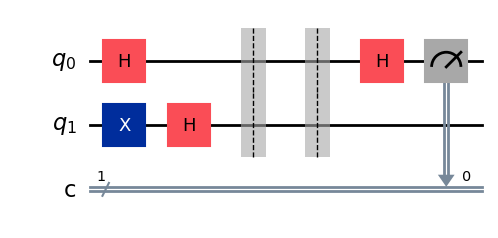

Caso 2 — esperado: constante


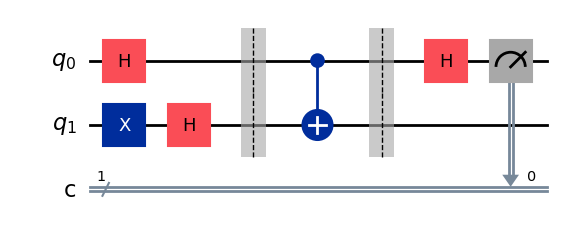

Caso 3 — esperado: balanceada


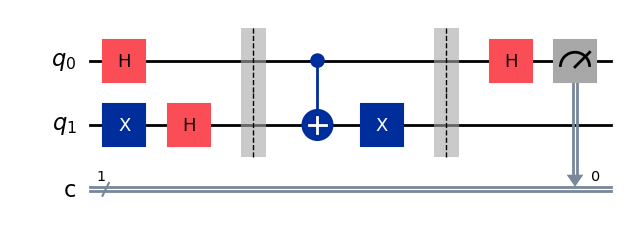

Caso 4 — esperado: balanceada


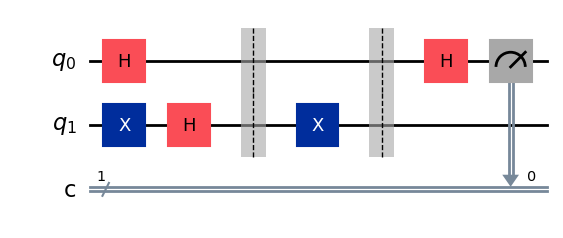

In [ ]:
# ── Funções do Algoritmo de Deutsch (revisão) ───────────────────
from qiskit import QuantumCircuit

def deutsch_oracle(case: int) -> QuantumCircuit:
    """Cria o oráculo de Deutsch para os 4 casos possíveis."""
    if case not in [1, 2, 3, 4]:
        raise ValueError("case deve ser 1, 2, 3 ou 4")
    f = QuantumCircuit(2)
    if case in [2, 3]:
        f.cx(0, 1)
    if case in [3, 4]:
        f.x(1)
    return f

def deutsch_circuit(oracle: QuantumCircuit) -> QuantumCircuit:
    """Monta o circuito completo do algoritmo de Deutsch."""
    qc = QuantumCircuit(2, 1)
    qc.x(1)           # Prepara ancilla em |1>
    qc.h([0, 1])      # Hadamard em ambos
    qc.barrier()
    qc.compose(oracle, inplace=True)  # Aplica o oráculo
    qc.barrier()
    qc.h(0)           # Hadamard no qubit de consulta
    qc.measure(0, 0)  # Mede o qubit 0
    return qc

# Mostra os 4 circuitos
for i in range(1, 5):
    qc = deutsch_circuit(deutsch_oracle(i))
    tipo = 'constante' if i in [1, 2] else 'balanceada'
    print(f"Caso {i} — esperado: {tipo}")
    display(qc.draw("mpl"))


### 5.1 Execução Ideal (Sem Ruído)

In [ ]:
# ── Simulação Ideal ─────────────────────────────────────────────
sim_ideal = AerSimulator()  # sem noise_model = perfeito

SHOTS = 1024
resultados_ideal = {}

for case in range(1, 5):
    oracle    = deutsch_oracle(case)
    qc        = deutsch_circuit(oracle)
    result    = sim_ideal.run(qc, shots=SHOTS).result()
    counts    = result.get_counts()
    conclusao = "constante" if counts.get("0", 0) > counts.get("1", 0) else "balanceada"
    resultados_ideal[case] = {"counts": counts, "conclusao": conclusao}
    tipo_esperado = "constante" if case in [1, 2] else "balanceada"

    print(f"Caso {case}: {counts}  →  {conclusao} {acerto}")

print("\n Sem ruído: resultado sempre correto.")


Caso 1: {'0': 1024}  →  constante 
Caso 2: {'1': 1024}  →  balanceada 
Caso 3: {'1': 1024}  →  balanceada 
Caso 4: {'0': 1024}  →  constante 

 Sem ruído: resultado sempre correto.


### 5.2 Execução com Ruído Customizado (Depolarização)

In [ ]:
def rodar_deutsch_com_ruido(case, p_dep, shots=1024):
    """Executa o Algoritmo de Deutsch com depolarização."""
    noise_model = NoiseModel()

    max_1q = 1.0          # limite para 1 qubit
    max_2q = 16/15        # ≈ 1.0667 — limite para 2 qubits (4²-1)/(4²) * (4/3)

    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(min(p_dep, max_1q), 1), ["h", "x"]
    )
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(min(p_dep * 3, max_2q), 2), ["cx"]
    )
    noise_model.add_all_qubit_readout_error(
        ReadoutError([[1-p_dep, p_dep], [p_dep, 1-p_dep]])
    )

    sim = AerSimulator(noise_model=noise_model)
    oracle = deutsch_oracle(case)
    qc     = deutsch_circuit(oracle)
    result = sim.run(qc, shots=shots).result()
    return result.get_counts()


# Testando com diferentes níveis de ruído no caso CONSTANTE (1)
niveis = [0.0, 0.01, 0.05, 0.10, 0.20, 0.40]
print("Caso CONSTANTE (caso 1) — esperado: maioria de '0'")
print(f"{'Ruído p':>12} | {'Contagem 0':>10} | {'Contagem 1':>10} | {'Correto?':>10}")
print("-" * 52)
for p in niveis:
    counts = rodar_deutsch_com_ruido(1, p)
    c0 = counts.get("0", 0)
    c1 = counts.get("1", 0)
    correto = "Sim" if c0 > c1 else "Não"
    print(f"{p:>12.2f} | {c0:>10} | {c1:>10} | {correto:>10}")

Caso CONSTANTE (caso 1) — esperado: maioria de '0'
     Ruído p | Contagem 0 | Contagem 1 |   Correto?
----------------------------------------------------
        0.00 |       1024 |          0 |        Sim
        0.01 |       1003 |         21 |        Sim
        0.05 |        931 |         93 |        Sim
        0.10 |        806 |        218 |        Sim
        0.20 |        709 |        315 |        Sim
        0.40 |        564 |        460 |        Sim


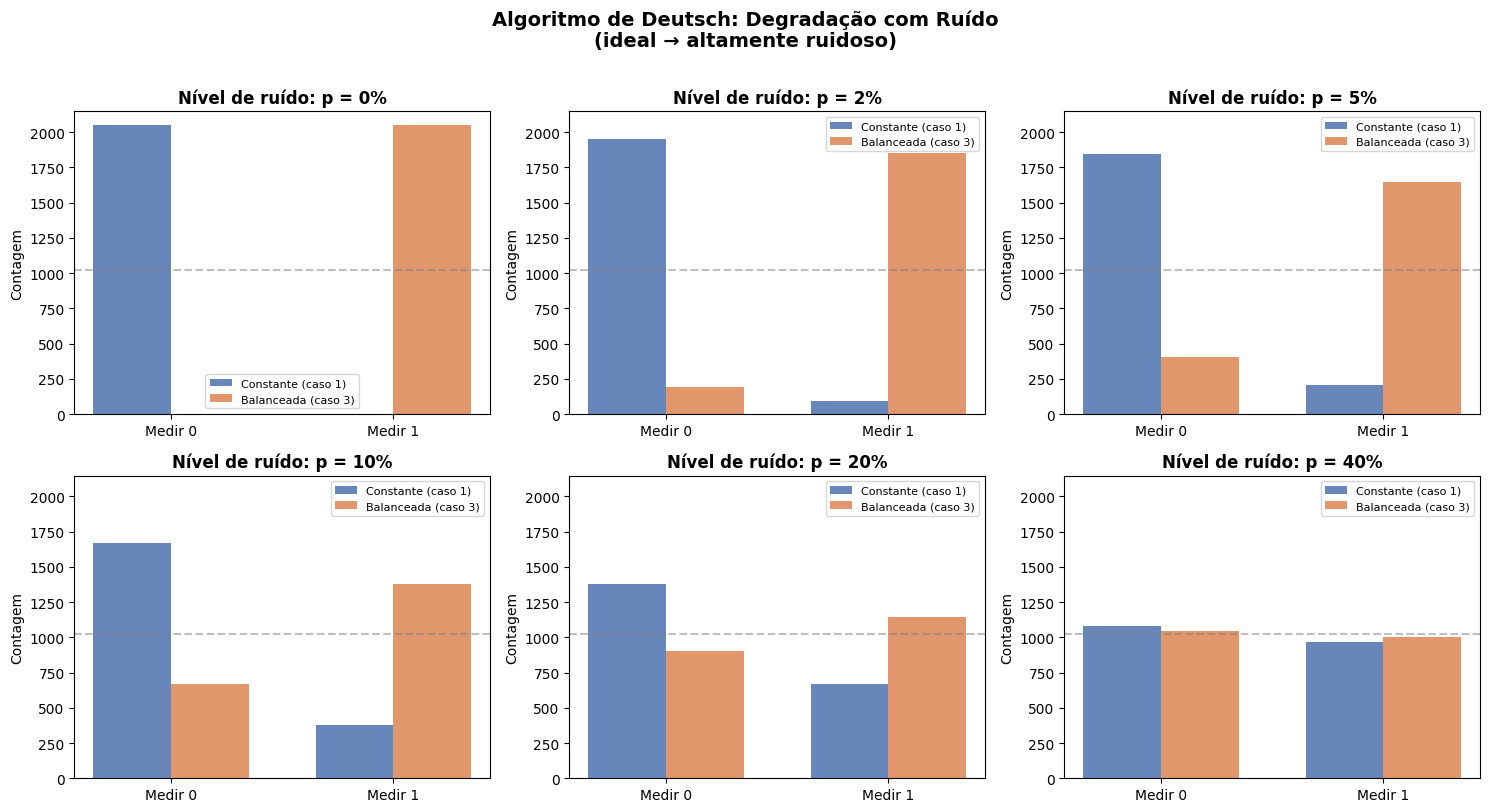


💡 Com p=40% o algoritmo fica inútil — resultados ~50/50!


In [ ]:
# Gráfico: como o ruído degrada o resultado
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

SHOTS = 2048
niveis_plot = [0.0, 0.02, 0.05, 0.10, 0.20, 0.40]

for idx, p in enumerate(niveis_plot):
    counts_const = rodar_deutsch_com_ruido(1, p, shots=SHOTS)
    counts_balan = rodar_deutsch_com_ruido(3, p, shots=SHOTS)

    estados  = ["0", "1"]
    val_const = [counts_const.get(s, 0) for s in estados]
    val_balan = [counts_balan.get(s, 0) for s in estados]

    x = np.arange(2)
    w = 0.35
    axes[idx].bar(x - w/2, val_const, w, label="Constante (caso 1)", color="#4C72B0", alpha=0.85)
    axes[idx].bar(x + w/2, val_balan, w, label="Balanceada (caso 3)", color="#DD8452", alpha=0.85)
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(["Medir 0", "Medir 1"])
    axes[idx].set_ylim(0, SHOTS + 100)
    axes[idx].set_title(f"Nível de ruído: p = {p:.0%}", fontsize=12, fontweight="bold")
    axes[idx].set_ylabel("Contagem")
    axes[idx].legend(fontsize=8)
    axes[idx].axhline(SHOTS / 2, color="gray", linestyle="--", alpha=0.5)

plt.suptitle("Algoritmo de Deutsch: Degradação com Ruído\n(ideal → altamente ruidoso)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()
print("\n💡 Com p=40% o algoritmo fica inútil — resultados ~50/50!")


### 5.3 Execução no FakeNairobi (Hardware Real Simulado)

In [ ]:
# ── FakeNairobi como Simulador ──────────────────────────────────
from qiskit_ibm_runtime.fake_provider import FakeNairobiV2
from qiskit.compiler import transpile

fake_nairobi   = FakeNairobiV2()
sim_nairobi    = AerSimulator.from_backend(fake_nairobi)

print(f"Simulando em: {fake_nairobi.name} ({fake_nairobi.num_qubits} qubits)\n")

SHOTS = 2048
resultados_nairobi = {}

for case in range(1, 5):
    oracle       = deutsch_oracle(case)
    qc           = deutsch_circuit(oracle)
    qc_transpiled = transpile(qc, backend=sim_nairobi, optimization_level=1)

    result    = sim_nairobi.run(qc_transpiled, shots=SHOTS).result()
    counts    = result.get_counts()
    c0        = counts.get("0", 0)
    c1        = counts.get("1", 0)
    conclusao = "constante" if c0 > c1 else "balanceada"
    esperado  = "constante" if case in [1, 2] else "balanceada"
    acerto    = "" if conclusao == esperado else ""

    resultados_nairobi[case] = {"counts": counts, "conclusao": conclusao}
    print(f"Caso {case}: {counts}  →  {conclusao} {acerto}  (esperado: {esperado})")


Simulando em: fake_nairobi (7 qubits)

Caso 1: {'1': 124, '0': 1924}  →  constante   (esperado: constante)
Caso 2: {'0': 127, '1': 1921}  →  balanceada   (esperado: constante)
Caso 3: {'0': 139, '1': 1909}  →  balanceada   (esperado: balanceada)
Caso 4: {'1': 124, '0': 1924}  →  constante   (esperado: balanceada)


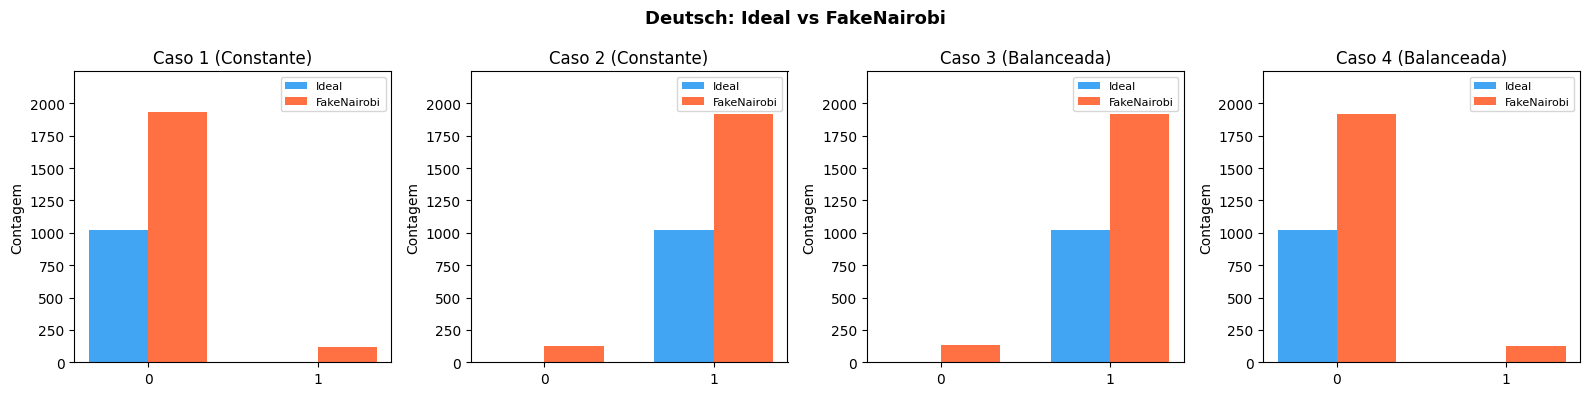

In [ ]:
# Comparação visual: Ideal vs FakeNairobi
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for case in range(1, 5):
    ax = axes[case - 1]
    c_ideal   = resultados_ideal[case]["counts"]
    c_nairobi = resultados_nairobi[case]["counts"]

    estados   = ["0", "1"]
    v_ideal   = [c_ideal.get(s, 0)   for s in estados]
    v_nairobi = [c_nairobi.get(s, 0) for s in estados]

    x = np.arange(2)
    w = 0.35
    ax.bar(x - w/2, v_ideal,   w, label="Ideal",       color="#2196F3", alpha=0.85)
    ax.bar(x + w/2, v_nairobi, w, label="FakeNairobi", color="#FF5722", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(["0", "1"])
    ax.set_ylabel("Contagem")
    tipo = "Constante" if case in [1, 2] else "Balanceada"
    ax.set_title(f"Caso {case} ({tipo})")
    ax.legend(fontsize=8)
    ax.set_ylim(0, SHOTS + 200)

plt.suptitle("Deutsch: Ideal vs FakeNairobi", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 6. Mitigação de Erros

Existem técnicas para reduzir o impacto do ruído **sem precisar de hardware perfeito**.

### Técnicas principais

| Técnica | Como funciona | Custo |
|---|---|---|
| **Repetição de shots** | Mais shots = estatística melhor | Mais tempo |
| **Transpilação otimizada** | Menos portas = menos ruído acumulado | Compilação |
| **Zero-Noise Extrapolation (ZNE)** | Amplifica o ruído e extrapola para zero | Mais circuitos |
| **Readout calibration** | Mede e corrige os erros de leitura | Calibração extra |


### 6.1 Efeito do Número de Shots na Confiabilidade

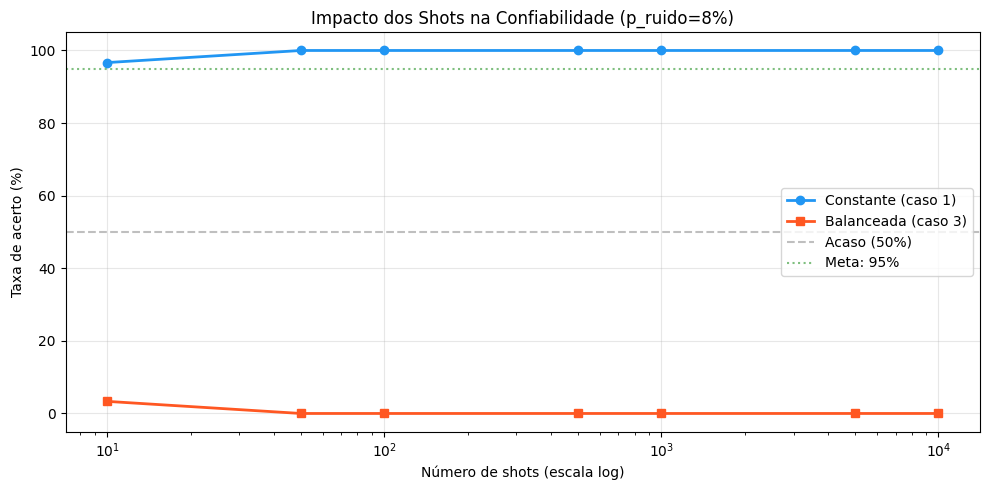


 Com ruído de 8%, precisamos de muitos shots para acima de 90% de acerto.


In [ ]:
# ── Impacto dos Shots ────────────────────────────────────────────
p_ruido = 0.08        # 8% de ruído — nível médio
shots_list = [10, 50, 100, 500, 1000, 5000, 10000]
acertos_constante  = []
acertos_balanceada = []

for shots in shots_list:
    acertos_c = 0
    acertos_b = 0
    N_rep = 30  # repetições para estimar probabilidade
    for _ in range(N_rep):
        c = rodar_deutsch_com_ruido(1, p_ruido, shots=shots)
        b = rodar_deutsch_com_ruido(3, p_ruido, shots=shots)
        if c.get("0", 0) > c.get("1", 0): acertos_c += 1
        if b.get("0", 0) > b.get("1", 0): acertos_b += 1
    acertos_constante.append(acertos_c / N_rep * 100)
    acertos_balanceada.append(acertos_b / N_rep * 100)

plt.figure(figsize=(10, 5))
plt.semilogx(shots_list, acertos_constante,  "o-", label="Constante (caso 1)", color="#2196F3", lw=2)
plt.semilogx(shots_list, acertos_balanceada, "s-", label="Balanceada (caso 3)", color="#FF5722", lw=2)
plt.axhline(50, color="gray",  linestyle="--", alpha=0.5, label="Acaso (50%)")
plt.axhline(95, color="green", linestyle=":",  alpha=0.5, label="Meta: 95%")
plt.xlabel("Número de shots (escala log)")
plt.ylabel("Taxa de acerto (%)")
plt.title(f"Impacto dos Shots na Confiabilidade (p_ruido={p_ruido:.0%})")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"\n Com ruído de {p_ruido:.0%}, precisamos de muitos shots para acima de 90% de acerto.")


### 6.2 Transpilação Otimizada: Menos Portas = Menos Ruído

In [ ]:
# ── Comparando níveis de otimização da transpilação ──────────────
from qiskit.compiler import transpile

oracle = deutsch_oracle(3)
qc     = deutsch_circuit(oracle)

print("=== Profundidade do circuito com diferentes níveis de otimização ===\n")
print(f"Original (sem transpilação):")
print(f"  Portas:       {qc.count_ops()}")
print(f"  Profundidade: {qc.depth()}\n")

for opt in [0, 1, 2, 3]:
    qc_t = transpile(qc, backend=sim_nairobi, optimization_level=opt)
    print(f"Optimization level {opt}:")
    print(f"  Portas:       {qc_t.count_ops()}")
    print(f"  Profundidade: {qc_t.depth()}")
    print()


=== Profundidade do circuito com diferentes níveis de otimização ===

Original (sem transpilação):
  Portas:       OrderedDict({'h': 3, 'x': 2, 'barrier': 2, 'cx': 1, 'measure': 1})
  Profundidade: 6

Optimization level 0:
  Portas:       OrderedDict({'rz': 6, 'sx': 3, 'x': 2, 'barrier': 2, 'cx': 1, 'measure': 1})
  Profundidade: 10

Optimization level 1:
  Portas:       OrderedDict({'rz': 6, 'sx': 3, 'barrier': 2, 'cx': 1, 'x': 1, 'measure': 1})
  Profundidade: 9

Optimization level 2:
  Portas:       OrderedDict({'rz': 6, 'sx': 3, 'barrier': 2, 'cx': 1, 'x': 1, 'measure': 1})
  Profundidade: 9

Optimization level 3:
  Portas:       OrderedDict({'rz': 6, 'sx': 3, 'barrier': 2, 'cx': 1, 'x': 1, 'measure': 1})
  Profundidade: 9



In [ ]:
# Rodando Deutsch no FakeNairobi com e sem otimização
for opt in [0, 1, 2, 3]:
    acertos = 0
    N = 20
    SHOTS_OPT = 1024
    for _ in range(N):
        oracle = deutsch_oracle(3)
        qc     = deutsch_circuit(oracle)
        qc_t   = transpile(qc, backend=sim_nairobi, optimization_level=opt)
        result = sim_nairobi.run(qc_t, shots=SHOTS_OPT).result()
        counts = result.get_counts()
        # caso 3 é balanceado: resposta correta = maioria de '1'
        if counts.get("1", 0) > counts.get("0", 0):
            acertos += 1
    taxa = acertos / N * 100
    print(f"Optimization level {opt}: {taxa:.0f}% de acerto em {N} execuções")


Optimization level 0: 100% de acerto em 20 execuções
Optimization level 1: 100% de acerto em 20 execuções
Optimization level 2: 100% de acerto em 20 execuções
Optimization level 3: 100% de acerto em 20 execuções


### 6.3 Mitigação de Erro de Leitura (Readout Calibration)

In [ ]:
# ── Correção de Erro de Medição ─────────────────────────────────
p_read = 0.15  # 15% de erro (alto, para fins de demonstração)
noise_readout = NoiseModel()
noise_readout.add_all_qubit_readout_error(
    ReadoutError([[1-p_read, p_read], [p_read, 1-p_read]])
)
sim_readout = AerSimulator(noise_model=noise_readout)

# Passo 1: Calibração — medir |0> e |1> puros
SHOTS_CAL = 4096
qc_cal_0 = QuantumCircuit(1, 1); qc_cal_0.measure(0, 0)
qc_cal_1 = QuantumCircuit(1, 1); qc_cal_1.x(0); qc_cal_1.measure(0, 0)

res_0 = sim_readout.run(qc_cal_0, shots=SHOTS_CAL).result().get_counts()
res_1 = sim_readout.run(qc_cal_1, shots=SHOTS_CAL).result().get_counts()

p00 = res_0.get("0", 0) / SHOTS_CAL
p10 = res_0.get("1", 0) / SHOTS_CAL  # erro!
p01 = res_1.get("0", 0) / SHOTS_CAL  # erro!
p11 = res_1.get("1", 0) / SHOTS_CAL

print("=== Matriz de Calibração Estimada ===")
print(f"P(0|0)={p00:.3f}  P(1|0)={p10:.3f}  ← ERRO")
print(f"P(0|1)={p01:.3f}  ← ERRO  P(1|1)={p11:.3f}")

# Passo 2: Rodar circuito real (Hadamard) e coletar resultados ruidosos
SHOTS_MAIN = 4096
qc_h = QuantumCircuit(1, 1); qc_h.h(0); qc_h.measure(0, 0)
res_h = sim_readout.run(qc_h, shots=SHOTS_MAIN).result().get_counts()
n0_ruidoso = res_h.get("0", 0)
n1_ruidoso = res_h.get("1", 0)
print(f"\nResultado ruidoso (H|0>): 0={n0_ruidoso}  1={n1_ruidoso}")

# Passo 3: Inverter a matriz de calibração para corrigir
A = np.array([[p00, p01], [p10, p11]])
b = np.array([n0_ruidoso, n1_ruidoso], dtype=float)
corrigido = np.clip(np.linalg.solve(A, b), 0, None)
print(f"\nResultado CORRIGIDO (mitigado): 0={corrigido[0]:.1f}  1={corrigido[1]:.1f}")
print(f"Ideal esperado: ~{SHOTS_MAIN//2} de cada")


=== Matriz de Calibração Estimada ===
P(0|0)=0.851  P(1|0)=0.149  ← ERRO
P(0|1)=0.136  ← ERRO  P(1|1)=0.864

Resultado ruidoso (H|0>): 0=2019  1=2077

Resultado CORRIGIDO (mitigado): 0=2045.9  1=2050.1
Ideal esperado: ~2048 de cada


## 7. Experimento Bônus: Estado de Bell com Ruído

O **estado de Bell** (emaranhamento máximo) é extremamente sensível a ruído.
Vamos observar sua degradação.

O estado ideal é:

$$|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}$$

Apenas os estados `|00>` e `|11>` devem aparecer. Qualquer `|01>` ou `|10>` é erro.


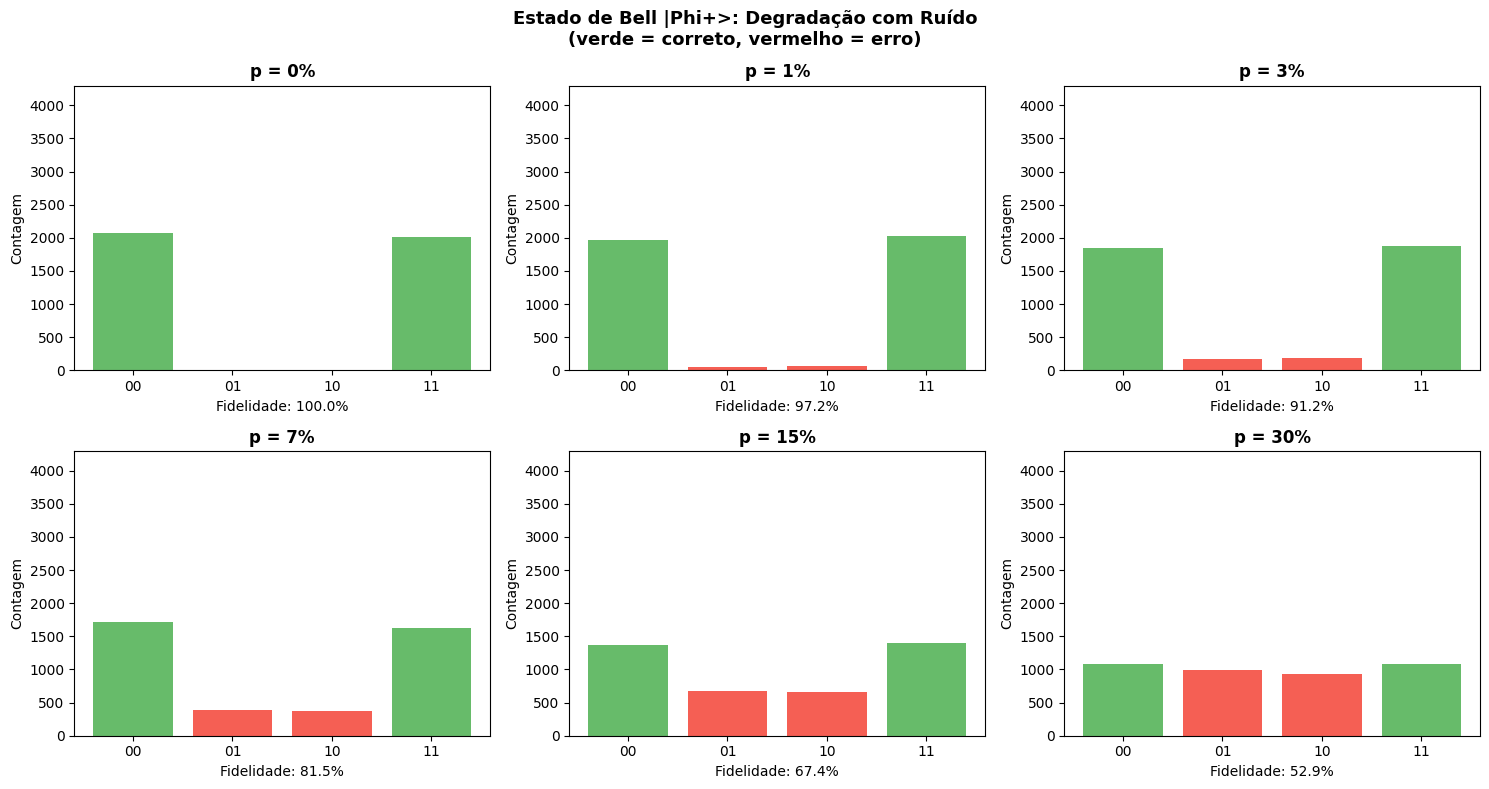


 Com p=30%, o emaranhamento quase desaparece — todos os estados ficam equiprováveis.


In [ ]:
# ── Estado de Bell: Ideal vs Ruidoso ────────────────────────────
def circuito_bell():
    qc = QuantumCircuit(2, 2)
    qc.h(0)
    qc.cx(0, 1)
    qc.measure([0, 1], [0, 1])
    return qc

SHOTS = 4096
niveis_bell = [0.0, 0.01, 0.03, 0.07, 0.15, 0.30]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, p in enumerate(niveis_bell):
    qc_b = circuito_bell()
    if p == 0.0:
        sim_b = AerSimulator()
    else:
        nm = NoiseModel()
        nm.add_all_qubit_quantum_error(depolarizing_error(p, 1),   ["h"])
        nm.add_all_qubit_quantum_error(depolarizing_error(p*2, 2), ["cx"])
        nm.add_all_qubit_readout_error(ReadoutError([[1-p, p], [p, 1-p]]))
        sim_b = AerSimulator(noise_model=nm)

    counts = sim_b.run(qc_b, shots=SHOTS).result().get_counts()

    estados = ["00", "01", "10", "11"]
    valores  = [counts.get(s, 0) for s in estados]
    cores    = ["#4CAF50" if s in ["00", "11"] else "#f44336" for s in estados]

    axes[idx].bar(estados, valores, color=cores, alpha=0.85)
    axes[idx].set_title(f"p = {p:.0%}", fontsize=12, fontweight="bold")
    axes[idx].set_ylabel("Contagem")
    axes[idx].set_ylim(0, SHOTS + 200)

    fidelidade = (counts.get("00", 0) + counts.get("11", 0)) / SHOTS
    axes[idx].set_xlabel(f"Fidelidade: {fidelidade:.1%}", fontsize=10)

plt.suptitle("Estado de Bell |Phi+>: Degradação com Ruído\n(verde = correto, vermelho = erro)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print("\n Com p=30%, o emaranhamento quase desaparece — todos os estados ficam equiprováveis.")


## 8. Resumo Comparativo: Ideal vs Vários Backends

In [ ]:
# ── Tabela Comparativa Final ────────────────────────────────────
from qiskit_ibm_runtime.fake_provider import FakeVigoV2, FakeNairobiV2

SHOTS_COMP = 2048
case_comp  = 3  # balanceado — resposta correta = maioria de '1'

# Modelo de ruído leve para comparação
nm_leve = NoiseModel()
nm_leve.add_all_qubit_quantum_error(depolarizing_error(0.01, 1), ["h", "x"])
nm_leve.add_all_qubit_quantum_error(depolarizing_error(0.03, 2), ["cx"])

backends_comp = {
    "Ideal":             AerSimulator(),
    "Ruido leve (1%)":   AerSimulator(noise_model=nm_leve),
    "FakeVigo":          AerSimulator.from_backend(FakeVigoV2()),
    "FakeNairobi":       AerSimulator.from_backend(FakeNairobiV2()),
}

print(f"{'Backend':<22} | {'Mediu 0':>8} | {'Mediu 1':>8} | {'Resultado':>12} | Correto?")
print("-" * 68)

for nome, sim_b in backends_comp.items():
    oracle = deutsch_oracle(case_comp)
    qc     = deutsch_circuit(oracle)
    try:
        qc_t   = transpile(qc, backend=sim_b, optimization_level=1)
        result = sim_b.run(qc_t, shots=SHOTS_COMP).result()
    except Exception:
        result = sim_b.run(qc,   shots=SHOTS_COMP).result()

    counts    = result.get_counts()
    c0        = counts.get("0", 0)
    c1        = counts.get("1", 0)
    conclusao = "constante" if c0 > c1 else "balanceada"
    correto   = "Sim" if conclusao == "balanceada" else "Não"
    print(f"{nome:<22} | {c0:>8} | {c1:>8} | {conclusao:>12} | {correto}")


Backend                |  Mediu 0 |  Mediu 1 |    Resultado | Correto?
--------------------------------------------------------------------
Ideal                  |        0 |     2048 |   balanceada | Sim
Ruido leve (1%)        |       73 |     1975 |   balanceada | Sim
FakeVigo               |      169 |     1879 |   balanceada | Sim
FakeNairobi            |      129 |     1919 |   balanceada | Sim


## 9. Exemplos

### Exemplo 1 — Ruído no Circuito de Toffoli

Crie o circuito da porta Toffoli (revisado na Aula 01) com os controles em |1⟩|1⟩.  
Execute-o com 3 modelos de ruído (p = 0.01, 0.05, 0.15) e calcule a **fidelidade** em cada caso  
(fração de medições que mostram o resultado correto `111`).


In [ ]:
# ── Exercício 1: Toffoli com Ruído ──────────────────────────────
# COMPLETE O CÓDIGO ABAIXO

def circuito_toffoli():
    qc = QuantumCircuit('x', 'x')
    # Coloque os controles em |1>|1>

    # Aplica Toffoli


SHOTS_EX1 = 2048
niveis_ex1 = [0.0, 0.01, 0.05, 0.15]

print(f"{'Ruído p':>10} | {'Contagem 111':>12} | {'Fidelidade':>12}")
print("-" * 42)

for p in niveis_ex1:
    qc_tof = circuito_toffoli()
    if p == 0.0:
        sim_ex1 = AerSimulator()
    else:
        nm_ex1 = NoiseModel()
        # ... adicione ruído aqui ...


    counts = sim_ex1.run(qc_tof, shots=SHOTS_EX1).result().get_counts()
    n_correto = counts.get("111", 0)
    fidelidade = n_correto / SHOTS_EX1
    print(f"{p:>10.2f} | {n_correto:>12} | {fidelidade:>11.1%}")


   Ruído p | Contagem 111 |   Fidelidade
------------------------------------------
      0.00 |         2048 |      100.0%
      0.01 |         1931 |       94.3%
      0.05 |         1442 |       70.4%
      0.15 |          734 |       35.8%


### Exemplo 2 — FakeVigo vs FakeNairobi no Estado de Bell

Rode o circuito de Bell nos backends `FakeVigo` e `FakeNairobi`.  
Calcule a fidelidade em cada um e discuta: qual apresenta menos ruído? Por que?  
**Dica:** Pesquise a data de calibração e o número de qubits de cada backend.


In [ ]:
# ── Exercício 2: Bell nos Fake Backends ─────────────────────────
from qiskit_ibm_runtime.fake_provider import FakeVigoV2, FakeNairobiV2
#Adicione os dois fake backends
fake_backends_ex2 = {
    "FakeVigo":    ,
    "FakeNairobi": ,
}

SHOTS_EX2 = #defina os shots

print(f"{'Backend':<15} | {'|00>':>6} | {'|01>':>6} | {'|10>':>6} | {'|11>':>6} | {'Fidelidade':>10}")
print("-" * 65)

for nome, sim_b in fake_backends_ex2.items():
    qc_b = circuito_bell()
    qc_t = transpile(qc_b, backend=sim_b, optimization_level=1)
    counts = sim_b.run(qc_t, shots=SHOTS_EX2).result().get_counts()

    n00 = counts.get("00", 0)
    n01 = counts.get("01", 0)
    n10 = counts.get("10", 0)
    n11 = counts.get("11", 0)
    fidelidade = (n00 + n11) / SHOTS_EX2

    print(f"{nome:<15} | {n00:>6} | {n01:>6} | {n10:>6} | {n11:>6} | {fidelidade:>9.1%}")

print("\n Discussão: qual backend é menos ruidoso? O que isso implica para algoritmos reais?")


Backend         |   |00> |   |01> |   |10> |   |11> | Fidelidade
-----------------------------------------------------------------
FakeVigo        |   3772 |    416 |    423 |   3581 |     89.8%
FakeNairobi     |   3798 |    316 |    332 |   3746 |     92.1%

 Discussão: qual backend é menos ruidoso? O que isso implica para algoritmos reais?


### Exercício 3 — Construa seu Próprio Modelo de Ruído

Crie um modelo de ruído combinando:
- Depolarização de **2%** em portas de 1 qubit
- Depolarização de **8%** no CNOT  
- Erro de leitura de **5%**

Depois rode o Algoritmo de Deutsch para todos os 4 casos e conte quantos acertam.  
Repita 50 vezes e calcule a taxa de acerto média.


In [ ]:
# ── Exercício 3: Modelo de Ruído Customizado ───────────────────
# COMPLETE O CÓDIGO ABAIXO

noise_ex3 = NoiseModel()
# Adicione os erros:
# 2% dep 1q
# 8% dep cx
# 5% readout

sim_ex3 = AerSimulator(noise_model=noise_ex3)

N_EXPERIMENTOS = 50
total_acertos  = 0

for _ in range(N_EXPERIMENTOS):
    acertos_rodada = 0
    for case in range(1, 5):
        oracle    = deutsch_oracle(case)
        qc        = deutsch_circuit(oracle)
        result    = sim_ex3.run(qc, shots=512).result()
        counts    = result.get_counts()
        # Avalia:
        c0        = counts.get("0", 0)
        c1        = counts.get("1", 0)
        conclusao = "constante" if c0 > c1 else "balanceada"
        esperado  = "constante" if case in [1, 2] else "balanceada"
        if conclusao == esperado:
            acertos_rodada += 1
    total_acertos += acertos_rodada

taxa_media = total_acertos / (N_EXPERIMENTOS * 4) * 100
print(f"Taxa de acerto com seu modelo de ruído: {taxa_media:.1f}%")
print(f"(média de {N_EXPERIMENTOS} execuções × 4 casos)")


Taxa de acerto com seu modelo de ruído: 50.0%
(média de 50 execuções × 4 casos)


### Comparativo dos Modelos de Ruído

| Modelo | Realismo | Velocidade | Quando usar |
|---|---|---|---|
| Sem ruído (ideal) |  Nenhum |  Muito rápido | Debug, prova de conceito |
| Depolarização simples |  Básico |  Rápido | Primeira análise de robustez |
| T1/T2 completo |  Alto |  Mais lento | Circuitos longos, timing |
| FakeNairobi/Vigo |  Muito alto |  Lento | Pré-validação para hardware real |


### Recursos

- [Qiskit Aer — Noise API](https://qiskit.github.io/qiskit-aer/apidocs/aer_noise.html)  
- [IBM Quantum Learning](https://learning.quantum.ibm.com/)  
- [Fake Providers](https://docs.quantum.ibm.com/api/qiskit-ibm-runtime/fake_provider)  
- [Error Mitigation — Qiskit](https://docs.quantum.ibm.com/guides/error-mitigation-and-suppression-techniques)
